In [1]:
# Trying ANN and turning in probabilities as Kaggle submission

# Loading Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Mounting Google Drive to Colab
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
# Verifying location of data
!ls /content/gdrive/MyDrive/DATA-4381/Data

app.py		    package.json	  train_identity.csv
model_features.pkl  package-lock.json	  train_transaction.csv
node_modules	    submission1.csv	  xgb_fraud_model.pkl
nohup.out	    test_identity.csv
oof_xgb_95.csv	    test_transaction.csv


In [4]:
# Changing current work directory
%cd /content/gdrive/MyDrive/DATA-4381/Data

/content/gdrive/MyDrive/DATA-4381/Data


In [5]:
# Loading datasets
df_txn = pd.read_csv('train_transaction.csv') # Transactions Dataset
df_id = pd.read_csv('train_identity.csv') # Identity Dataset

In [6]:
# Merging Transaction and Identity DataFrames
df = pd.merge(df_txn, df_id, on='TransactionID', how='left')

# Model

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from imblearn.over_sampling import SMOTE  # NEW: Import SMOTE
import gc

# --- 1. Load and Merge Data ---
# (Assumed df is already loaded)

# --- 2. Preprocessing ---

# Drop columns with excessive missing values
missing_threshold = 0.7
cols_to_drop = df.columns[df.isnull().sum() / df.shape[0] > missing_threshold]
train_df = df.drop(cols_to_drop, axis=1)

X = train_df.drop('isFraud', axis=1)
y = train_df['isFraud']

# Handle missing numerical values
for col in X.select_dtypes(include=np.number).columns:
    X[col] = X[col].fillna(X[col].mode()[0])

# Handle categorical features
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].fillna('Missing')
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# --- 3. Split, Resample, and Scale ---

# STEP 1: Split data FIRST (to prevent leakage)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# STEP 2: Apply SMOTE only to the TRAINING set
print("Applying SMOTE to balance training data...")
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_raw, y_train)

# STEP 3: Scale features AFTER resampling
# Note: Fit on training data only, then transform test data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_resampled)
X_test = scaler.transform(X_test_raw)

# --- 4. Build Neural Network Model ---

model = Sequential([
    Dense(256, input_dim=X_train.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['AUC'])

# --- 5. Train the model ---
print("Training the model...")

# When using SMOTE, the data is balanced, so high class_weights are often unnecessary.
# You can keep a mild weight or remove it entirely.
history = model.fit(
    X_train, y_train_resampled, # Using resampled data
    epochs=100,
    batch_size=512,
    validation_split=0.1,
    verbose=1
)

# --- 6. Evaluate the model ---
y_pred_probs = model.predict(X_test).ravel()
auc = roc_auc_score(y_test, y_pred_probs)
print(f"\nROC AUC Score on Test Data: {auc}")

Applying SMOTE to balance training data...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training the model...
Epoch 1/100
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - AUC: 0.9613 - loss: 0.2462 - val_AUC: 0.0000e+00 - val_loss: 0.1376
Epoch 2/100
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.9782 - loss: 0.1811 - val_AUC: 0.0000e+00 - val_loss: 0.1110
Epoch 3/100
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.9828 - loss: 0.1590 - val_AUC: 0.0000e+00 - val_loss: 0.0913
Epoch 4/100
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.9853 - loss: 0.1458 - val_AUC: 0.0000e+00 - val_loss: 0.1112
Epoch 5/100
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.9870 - loss: 0.1364 - val_AUC: 0.0000e+00 - val_loss: 0.0806
Epoch 6/100
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.9881 - loss: 0.1297 - val_AUC: 0.0000e+00 - val_loss: 0.0962
Epoch 7/100
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.9890 - loss: 0.1240 - val_AUC: 0.0000e+00 - val_loss: 0.0747
Epoch 8/100
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.9896 - loss: 0.1197 - val_AUC: 0.0000e

In [8]:
# Metrics
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix

# 1. Get raw probability scores from the model
y_probs = model.predict(X_test).flatten()

# 2. Convert probabilities to binary predictions (using 0.5 threshold)
y_preds = (y_probs > 0.5).astype(int)

# 3. Print the standard Classification Report (Precision, Recall, F1)
print("--- Classification Report ---")
print(classification_report(y_test, y_preds))

# 4. Calculate specialized AUC scores
roc_auc = roc_auc_score(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")

3691/3691 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    113975
           1       0.74      0.60      0.66      4133

    accuracy                           0.98    118108
   macro avg       0.86      0.80      0.82    118108
weighted avg       0.98      0.98      0.98    118108

ROC-AUC Score: 0.9290
PR-AUC (Average Precision): 0.6839


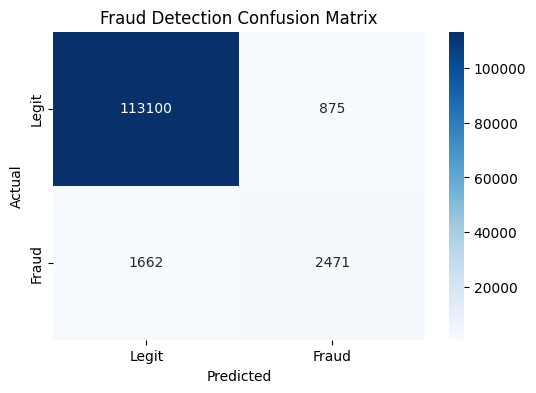

In [9]:
# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Fraud Detection Confusion Matrix')
plt.show()

# Preparing Kaggle Submission

In [11]:
# Loading Data
df_test_txn = pd.read_csv('test_transaction.csv')
df_test_id = pd.read_csv('test_identity.csv')
df_test = pd.merge(df_test_txn, df_test_id, on='TransactionID', how='left')

In [12]:
df_test.head()

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.00,W,4272,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.00,W,4476,574.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.95,W,10989,360.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.95,W,18018,452.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# Preprocessing Test Data

# Drop columns with excessive missing values
missing_threshold = 0.7
cols_to_drop_test = df_test.columns[df_test.isnull().sum() / df_test.shape[0] > missing_threshold]
df_test = df_test.drop(cols_to_drop_test, axis=1)

# Handle missing numerical values
for col in df_test.select_dtypes(include=np.number).columns:
    df_test[col] = df_test[col].fillna(df_test[col].mode()[0])

# Handle categorical features
for col in df_test.select_dtypes(include='object').columns:
    df_test[col] = df_test[col].fillna('Missing')
    le = LabelEncoder()
    df_test[col] = le.fit_transform(df_test[col])

# Using fitted scaler to scale testing data
df_test = scaler.transform(df_test)

In [14]:
# 1. Get raw probability scores from the model
y_probs_test = model.predict(df_test).flatten()

# 2. Convert probabilities to binary predictions (using 0.5 threshold)
y_preds_test = (y_probs_test > 0.5).astype(int)

15835/15835 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step


In [ ]:
y_probs_test

In [15]:
# Preparing submission
submission_probs1 = pd.DataFrame({
    'TransactionID': df_test_txn['TransactionID'],
    'isFraud': y_probs_test
})

In [16]:
submission_probs1

,TransactionID,isFraud
0,3663549,0.000245
1,3663550,0.000242
2,3663551,0.001668
3,3663552,0.000591
4,3663553,0.004856
...,...,...
506686,4170235,0.009566
506687,4170236,0.005590
506688,4170237,0.007924
506689,4170238,0.020920


In [17]:
# Converting to csv file
submission_probs1.to_csv('ann_submission_probs1.csv', index=False)